In [7]:
!pip install fredapi > /dev/null

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from fredapi import Fred
from getpass import getpass

plt.style.use("fivethirtyeight")

# Connect to FRED

In [9]:
fred_key = getpass("Enter your FRED API key: ")

fred = Fred(api_key=fred_key)

Enter your FRED API key: ··········


# Download State Unemployment Data


In [39]:
STATE_ABBR = [
    "AL","AK","AZ","AR","CA","CO","CT","DE","FL","GA",
    "HI","ID","IL","IN","IA","KS","KY","LA","ME","MD",
    "MA","MI","MN","MS","MO","MT","NE","NV","NH","NJ",
    "NM","NY","NC","ND","OH","OK","OR","PA","RI","SC",
    "SD","TN","TX","UT","VT","VA","WA","WV","WI","WY"
]

In [11]:
ABBR_TO_NAME = {
    "AL":"Alabama",
    "AK":"Alaska",
    "AZ":"Arizona",
    "AR":"Arkansas",
    "CA":"California",
    "CO":"Colorado",
    "CT":"Connecticut",
    "DE":"Delaware",
    "FL":"Florida",
    "GA":"Georgia",
    "HI":"Hawaii",
    "ID":"Idaho",
    "IL":"Illinois",
    "IN":"Indiana",
    "IA":"Iowa",
    "KS":"Kansas",
    "KY":"Kentucky",
    "LA":"Louisiana",
    "ME":"Maine",
    "MD":"Maryland",
    "MA":"Massachusetts",
    "MI":"Michigan",
    "MN":"Minnesota",
    "MS":"Mississippi",
    "MO":"Missouri",
    "MT":"Montana",
    "NE":"Nebraska",
    "NV":"Nevada",
    "NH":"New Hampshire",
    "NJ":"New Jersey",
    "NM":"New Mexico",
    "NY":"New York",
    "NC":"North Carolina",
    "ND":"North Dakota",
    "OH":"Ohio",
    "OK":"Oklahoma",
    "OR":"Oregon",
    "PA":"Pennsylvania",
    "RI":"Rhode Island",
    "SC":"South Carolina",
    "SD":"South Dakota",
    "TN":"Tennessee",
    "TX":"Texas",
    "UT":"Utah",
    "VT":"Vermont",
    "VA":"Virginia",
    "WA":"Washington",
    "WV":"West Virginia",
    "WI":"Wisconsin",
    "WY":"Wyoming",
    "DC":"District of Columbia"
}

FRED unemployment series id's

In [12]:
state_series = [
    f"{state}UR"
    for state in STATE_ABBR
] + ["DCUR"]

Download data

In [13]:
unemployment = pd.concat(
    [
        fred.get_series(series_id).rename(series_id)
        for series_id in state_series
    ],
    axis=1
)

Rename columns to state names

In [14]:
unemployment.columns = [
    ABBR_TO_NAME[col[:2]]
    for col in unemployment.columns
]
unemployment.head()

,Alabama,Alaska,Arizona,Arkansas,California,Colorado,Connecticut,Delaware,Florida,Georgia,...,Tennessee,Texas,Utah,Vermont,Virginia,Washington,West Virginia,Wisconsin,Wyoming,District of Columbia
1976-01-01,6.7,7.1,10.2,7.3,9.2,5.8,9.7,8.0,9.6,8.4,...,6.0,5.8,5.8,8.5,6.0,8.5,7.4,5.8,4.1,8.8
1976-02-01,6.6,7.1,10.2,7.3,9.2,5.8,9.7,8.0,9.7,8.4,...,6.0,5.8,5.9,8.5,6.0,8.5,7.4,5.8,4.1,8.8
1976-03-01,6.6,7.0,10.2,7.3,9.1,5.7,9.7,8.0,9.6,8.3,...,6.0,5.9,5.8,8.6,6.0,8.5,7.4,5.8,4.1,8.7
1976-04-01,6.5,7.0,10.0,7.2,9.0,5.6,9.6,8.2,9.5,8.2,...,6.0,5.9,5.8,8.5,5.9,8.5,7.4,5.7,4.0,8.6
1976-05-01,6.4,7.0,9.8,7.1,8.9,5.6,9.4,8.4,9.3,8.1,...,5.9,6.0,5.7,8.5,5.8,8.5,7.4,5.6,4.0,8.5


# Download State Labor-Force Participation Data

In [15]:
participation_info = fred.search(
    "Participation Rate - State",
    filter=("frequency", "Monthly")
)

Keep only seasonally adjusted percentage series

In [16]:
participation_info = participation_info.query(
    'seasonal_adjustment == "Seasonally Adjusted" and units == "Percent"'
)

Keep the state participation series

In [17]:
participation_info = participation_info.loc[
    participation_info.index.str.match(r"^LBSSA\d{2}$")
]

Create a mapping between FRED series IDs and state names

In [18]:
series_to_state = (
    participation_info["title"]
    .str.replace(
        "Labor Force Participation Rate for",
        "",
        regex=False
    )
    .str.strip()
    .to_dict()
)

Download the participation data

In [19]:
participation = pd.concat(
    [
        fred.get_series(series_id).rename(series_id)
        for series_id in participation_info.index
    ],
    axis=1
)

Rename columns

In [20]:
participation.columns = [
    series_to_state[col]
    for col in participation.columns
]
participation.head()

,Alabama,Georgia,Louisiana,Mississippi,California,Michigan,Ohio,Florida,Texas,Massachusetts,...,Montana,Rhode Island,Missouri,New Hampshire,Nevada,South Dakota,Wyoming,District Of Columbia,Delaware,North Dakota
1976-01-01,57.1,63.8,56.9,58.8,62.5,61.6,61.7,55.8,63.7,64.8,...,62.5,63.8,60.5,65.8,71.4,64.8,65.3,64.4,62.7,62.7
1976-02-01,56.9,63.6,56.7,58.6,62.4,61.5,61.6,55.6,63.5,64.7,...,62.4,63.7,60.4,65.6,70.8,64.7,65.0,64.5,62.6,62.5
1976-03-01,56.8,63.5,56.5,58.5,62.2,61.5,61.6,55.5,63.3,64.6,...,62.3,63.7,60.3,65.5,70.5,64.6,64.8,64.6,62.6,62.4
1976-04-01,56.8,63.6,56.5,58.5,62.2,61.6,61.6,55.4,63.4,64.6,...,62.1,63.7,60.4,65.6,70.5,64.6,65.0,64.6,62.5,62.5
1976-05-01,56.8,63.6,56.5,58.5,62.2,61.7,61.5,55.3,63.6,64.6,...,62.0,63.7,60.6,66.0,70.6,64.6,65.2,64.4,62.5,62.6


# Create the April 2019 vs. April 2020 Analysis Table

In [21]:
analysis_df = pd.DataFrame({
    "unemp_apr_2019": unemployment.loc["2019-04-01"],
    "unemp_apr_2020": unemployment.loc["2020-04-01"],
    "lfp_apr_2019": participation.loc["2019-04-01"],
    "lfp_apr_2020": participation.loc["2020-04-01"]
})
analysis_df = analysis_df.dropna()

Create unemployment shock

In [22]:
analysis_df["unemp_shock"] = (
    analysis_df["unemp_apr_2020"]
    - analysis_df["unemp_apr_2019"]
)

Create labor-force participation shock

In [23]:
analysis_df["lfp_shock"] = (
    analysis_df["lfp_apr_2020"]
    - analysis_df["lfp_apr_2019"]
)
analysis_df.head()

,unemp_apr_2019,unemp_apr_2020,lfp_apr_2019,lfp_apr_2020,unemp_shock,lfp_shock
Alabama,3.3,13.8,57.7,55.4,10.5,-2.3
Alaska,5.7,11.6,64.5,61.7,5.9,-2.8
Arizona,4.9,13.8,61.9,60.2,8.9,-1.7
Arkansas,3.4,10.1,58.1,57.7,6.7,-0.4
California,4.1,16.1,62.3,60.0,12.0,-2.3


# Find the States With the Largest Unemployment Shocks

In [24]:
largest_shocks = (
    analysis_df["unemp_shock"]
    .nlargest(15)
    .sort_values()
)

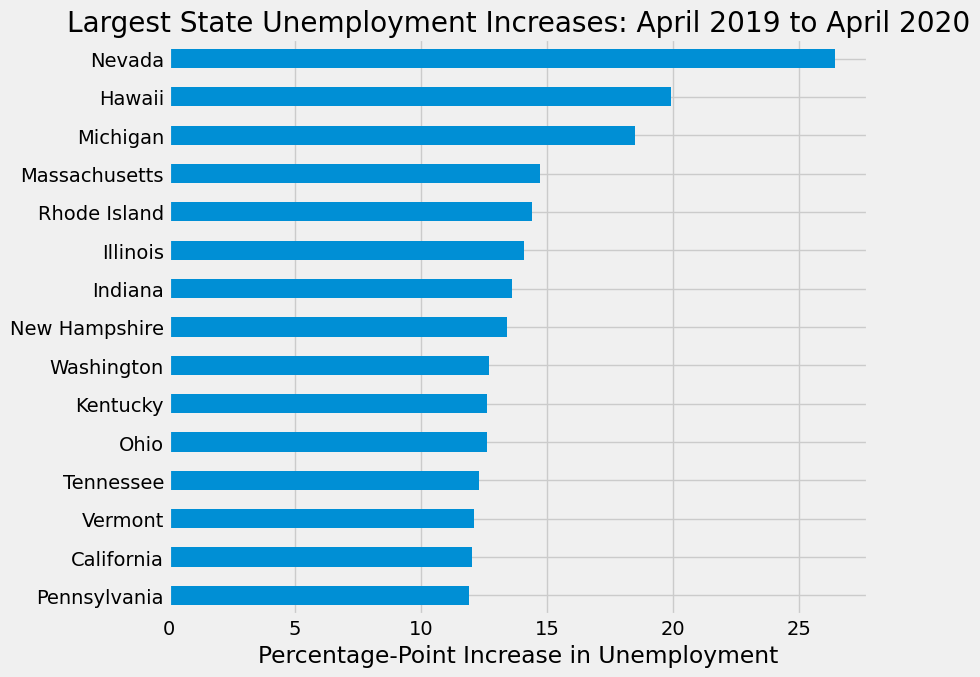

In [25]:
largest_shocks.plot(
    kind="barh",
    figsize=(9, 7),
    title="Largest State Unemployment Increases: April 2019 to April 2020"
)

plt.xlabel("Percentage-Point Increase in Unemployment")
plt.ylabel("")

plt.tight_layout()
plt.show()

# Compare Labor-Force Participation and Unemployment

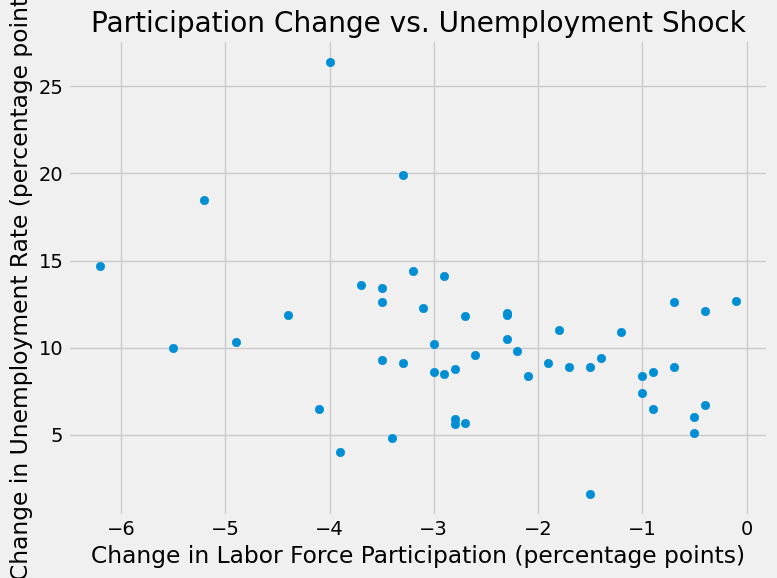

In [26]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["lfp_shock"],
    analysis_df["unemp_shock"]
)

plt.xlabel(
    "Change in Labor Force Participation (percentage points)"
)

plt.ylabel(
    "Change in Unemployment Rate (percentage points)"
)

plt.title(
    "Participation Change vs. Unemployment Shock"
)

plt.tight_layout()
plt.show()

# Run Linear Regression

In [27]:
X = analysis_df["lfp_shock"]
X = sm.add_constant(X)
y = analysis_df["unemp_shock"]
model = sm.OLS(y, X).fit()

In [28]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            unemp_shock   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.107
Method:                 Least Squares   F-statistic:                     6.844
Date:                Fri, 25 Sep 2026   Prob (F-statistic):             0.0119
Time:                        21:34:14   Log-Likelihood:                -138.66
No. Observations:                  50   AIC:                             281.3
Df Residuals:                      48   BIC:                             285.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.5485      1.144      6.601      0.0

# Add the Regression Line to the Scatterplot

In [29]:
x_values = np.linspace(
    analysis_df["lfp_shock"].min(),
    analysis_df["lfp_shock"].max(),
    100
)

In [30]:
y_values = (
    model.params["const"]
    + model.params["lfp_shock"] * x_values
)

Create the chart

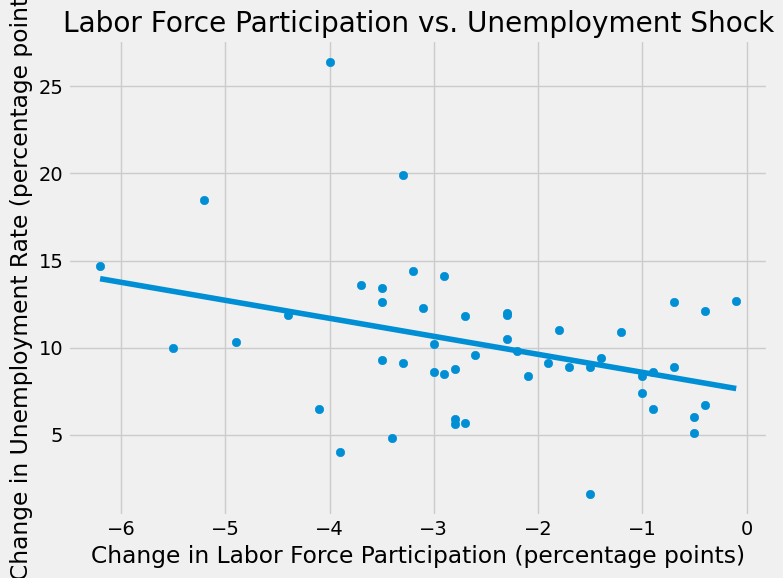

In [31]:
plt.figure(figsize=(8, 6))

plt.scatter(
    analysis_df["lfp_shock"],
    analysis_df["unemp_shock"]
)

plt.plot(
    x_values,
    y_values
)

plt.xlabel(
    "Change in Labor Force Participation (percentage points)"
)

plt.ylabel(
    "Change in Unemployment Rate (percentage points)"
)

plt.title(
    "Labor Force Participation vs. Unemployment Shock"
)

plt.tight_layout()
plt.show()

# Recovery Analysis

In [32]:
recovery_df = pd.DataFrame({
    "feb_2020": unemployment.loc["2020-02-01"],
    "apr_2020": unemployment.loc["2020-04-01"],
    "dec_2021": unemployment.loc["2021-12-01"]
})

Calculate the initial COVID shock

In [33]:
recovery_df["initial_shock"] = (
    recovery_df["apr_2020"]
    - recovery_df["feb_2020"]
)

Calculate how far unemployment was from its pre-COVID level by December 2021

In [34]:
recovery_df["remaining_gap_2021"] = (
    recovery_df["dec_2021"]
    - recovery_df["feb_2020"]
)
recovery_df.head()

,feb_2020,apr_2020,dec_2021,initial_shock,remaining_gap_2021
Alabama,3.3,13.8,2.7,10.5,-0.6
Alaska,5.4,11.6,5.4,6.2,0.0
Arizona,4.8,13.8,3.7,9.0,-1.1
Arkansas,3.6,10.1,3.2,6.5,-0.4
California,4.4,16.1,5.4,11.7,1.0


# Find the States Closest to Pre-COVID Unemployment

In [35]:
closest_to_pre_covid = (
    recovery_df["remaining_gap_2021"]
    .abs()
    .sort_values()
    .head(10)
)

In [36]:
recovery_df.loc[
    closest_to_pre_covid.index,
    [
        "feb_2020",
        "apr_2020",
        "dec_2021",
        "remaining_gap_2021"
    ]
]

,feb_2020,apr_2020,dec_2021,remaining_gap_2021
Alaska,5.4,11.6,5.4,0.0
Kentucky,4.1,16.7,4.1,0.0
North Carolina,3.8,14.2,3.8,0.0
North Dakota,2.2,8.7,2.3,0.1
Pennsylvania,4.6,16.1,4.5,-0.1
New Hampshire,2.6,16.0,2.5,-0.1
Maryland,3.4,9.0,3.5,0.1
Idaho,2.8,11.8,2.9,0.1
Rhode Island,3.6,17.9,3.7,0.1
Wisconsin,3.1,14.1,3.0,-0.1


# Recovery Chart

In [37]:
recovery_chart = recovery_df.loc[
    closest_to_pre_covid.index,
    "remaining_gap_2021"
].sort_values()

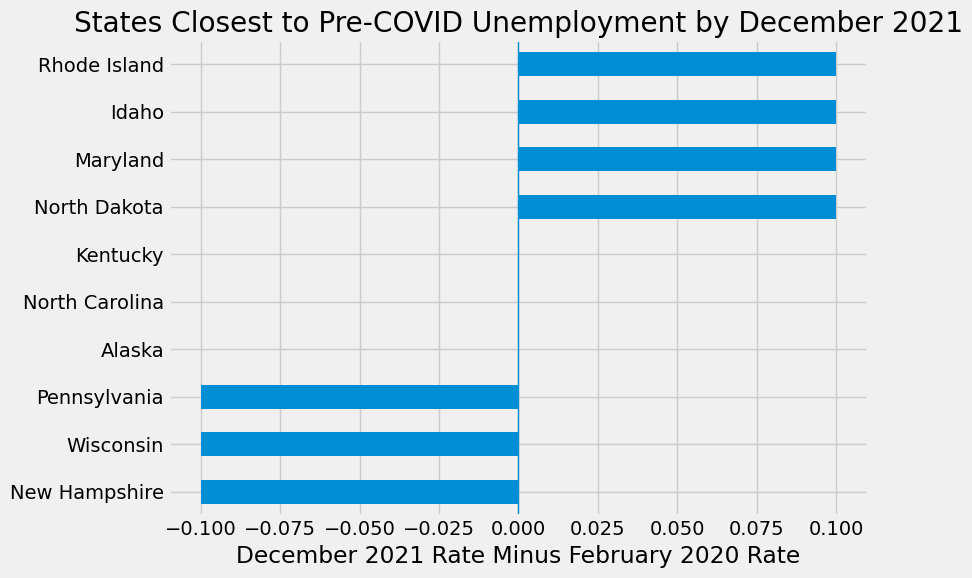

In [41]:
recovery_chart.plot(
    kind="barh",
    figsize=(9, 6),
    title="States Closest to Pre-COVID Unemployment by December 2021"
)

plt.axvline(0, linewidth=1)

plt.xlabel(
    "December 2021 Rate Minus February 2020 Rate"
)

plt.ylabel("")

plt.tight_layout()
plt.show()

# Key Findings

- States with larger declines in labor-force participation generally experienced larger increases in unemployment.
- The regression showed a statistically significant negative relationship between labor-force participation changes and unemployment shocks. The coefficient on participation change was about -1.03 with a p-value of 0.012. This means that, on average, a 1-percentage-point larger decline in labor-force participation was associated with about a 1.03-percentage-point larger unemployment increase. The model's R² was 0.125, so participation changes explained about 12.5% of the differences in unemployment shocks across states.